## Artificial Neural Network for Customer Churn Prediction

**Project:** Predict whether a customer will churn using a feed-forward Artificial Neural Network (ANN).

Dataset: IBM Telco Customer Churn dataset  
Suggested source: https://www.kaggle.com/datasets/blastchar/telco-customer-churn


## Setup



In [2]:
!pip install tensorflow scikit-learn pandas matplotlib seaborn -q

## Imports and configuration

In [3]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.callbacks import EarlyStopping

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

DATA_PATH = "WA_Fn-UseC_-Telco-Customer-Churn.csv"
TARGET = "Churn"


#### Load and inspect the data


In [4]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')


In [5]:
df.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
df.shape

(7043, 21)

In [7]:
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [9]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [10]:
df.isnull().sum().sum()

np.int64(0)

In [11]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

- The dataset contains 7043 entries. 
- It has no duplicate values. 
- The target column is Churn. It is not balanced as the Yes (the number of customers that left within the last month) values are 1869 and the No (the number of customers retained) values are 5174.

#### Clean the data



In [12]:
df["TotalCharges"] = pd.to_numeric(df['TotalCharges'], errors = 'coerce')


In [13]:
df = df.dropna(subset = ['TotalCharges'])
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [14]:
df['TotalCharges'].isnull().sum()

np.int64(0)

In [15]:
df.drop(columns=["customerID"], inplace=True)

In [16]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


#### Separate features and target


In [17]:
df[TARGET] = df[TARGET].map({
    'Yes' : 1, 'No' : 0
})


In [18]:
X = df.drop(columns = [TARGET])

In [19]:
y = df[TARGET]

In [20]:
print('X shape:', X.shape)

X shape: (7032, 19)


In [21]:
print('Y Shape:', y.shape)

Y Shape: (7032,)


In [22]:
print(y.value_counts())

Churn
0    5163
1    1869
Name: count, dtype: int64


#### Encode categorical variables


In [23]:
X = pd.get_dummies(X, drop_first=True)

In [24]:
X.dtypes

SeniorCitizen                              int64
tenure                                     int64
MonthlyCharges                           float64
TotalCharges                             float64
gender_Male                                 bool
Partner_Yes                                 bool
Dependents_Yes                              bool
PhoneService_Yes                            bool
MultipleLines_No phone service              bool
MultipleLines_Yes                           bool
InternetService_Fiber optic                 bool
InternetService_No                          bool
OnlineSecurity_No internet service          bool
OnlineSecurity_Yes                          bool
OnlineBackup_No internet service            bool
OnlineBackup_Yes                            bool
DeviceProtection_No internet service        bool
DeviceProtection_Yes                        bool
TechSupport_No internet service             bool
TechSupport_Yes                             bool
StreamingTV_No inter

In [25]:
X.shape

(7032, 30)

#### Train / validation / test split


In [26]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size = 0.3, random_state = SEED, stratify = y
)


In [27]:
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size = 0.5, random_state = SEED, stratify = y_temp
)

In [28]:
print('X_train', X_train)

X_train       SeniorCitizen  tenure  MonthlyCharges  TotalCharges  gender_Male  \
4499              0      12           78.30        909.25        False   
1933              0      20           19.70        415.90         True   
4668              0       2           61.20        125.95        False   
5681              1      34           64.20       2106.30        False   
3610              0      12          100.15       1164.30        False   
...             ...     ...             ...           ...          ...   
5161              0      23           54.15       1312.45         True   
3451              1      65           70.95       4555.20         True   
4135              0      36           92.90       3379.25        False   
4249              0      10           65.90        660.05        False   
272               0       1           24.80         24.80         True   

      Partner_Yes  Dependents_Yes  PhoneService_Yes  \
4499        False            True              T

In [29]:
print('X_temp', X_temp)

X_temp       SeniorCitizen  tenure  MonthlyCharges  TotalCharges  gender_Male  \
4221              0       1           19.30         19.30         True   
1820              0       6           45.65        323.45        False   
2375              1      71          109.70       7904.25        False   
5462              0      64           70.15       4480.70         True   
1791              0      44           61.50       2722.20        False   
...             ...     ...             ...           ...          ...   
4685              0      46          108.90       4854.30        False   
4768              1      71           19.80       1388.45         True   
6150              0      32           91.05       2871.50         True   
3234              0      24           19.70        452.55        False   
4451              1      45           93.90       4200.25         True   

      Partner_Yes  Dependents_Yes  PhoneService_Yes  \
4221        False           False              Tr

In [30]:
print('X_val', X_val)

X_val       SeniorCitizen  tenure  MonthlyCharges  TotalCharges  gender_Male  \
2114              0      40           61.90       2647.10         True   
2071              0      67           94.10       6302.80        False   
2505              0      34           20.10        682.10        False   
5645              0      64           66.15       4392.50         True   
2367              0       1           85.55         85.55        False   
...             ...     ...             ...           ...          ...   
6838              0      13           99.00       1301.70         True   
4321              1      14           80.35       1058.10        False   
8                 0      28          104.80       3046.05        False   
4768              1      71           19.80       1388.45         True   
1326              0      43           51.25       2151.60        False   

      Partner_Yes  Dependents_Yes  PhoneService_Yes  \
2114        False           False              Tru

In [31]:
print('X_test', X_test)

X_test       SeniorCitizen  tenure  MonthlyCharges  TotalCharges  gender_Male  \
2778              0      13           74.65        966.25        False   
715               0      46           89.15       4245.55         True   
153               0      62           86.10       5215.25         True   
3755              0       4           76.05        318.90         True   
4848              0       5           93.90        486.85        False   
...             ...     ...             ...           ...          ...   
5137              1      55          116.50       6382.55         True   
2093              0      10           24.80        223.90         True   
5625              0      22           20.55        469.85        False   
1150              0      41           40.35       1677.85        False   
6353              0      10           54.95        568.85         True   

      Partner_Yes  Dependents_Yes  PhoneService_Yes  \
2778        False           False              Tr

#### Standardize the numerical inputs


In [32]:
scaler = StandardScaler()

In [33]:
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [34]:
X_train_scaled = np.array(X_train_scaled)
X_val_scaled = np.array(X_val_scaled)
X_test_scaled = np.array(X_test_scaled)

In [35]:
y_train = np.array(y_train)
y_val = np.array(y_val)
y_test = np.array(y_test)

#### Build the Artificial Neural Network


In [36]:
def build_model(input_dim):
    model = models.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(64, activation = 'relu'),
        layers.Dropout(0.3),
        layers.Dense(32, activation ='relu'),
        layers.Dropout(0.2),
        layers.Dense(1, activation = 'sigmoid')
    ])

    model.compile(optimizer = 'adam', loss = 'binary_crossentropy', metrics = ['accuracy'])

    return model


In [37]:
model = build_model(X_train_scaled.shape[1])

In [38]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,097 (16.00 KB)

 Trainable params: 4,097 (16.00 KB)

 Non-trainable params: 0 (0.00 B)

#### Train the ANN


In [39]:
early_stop = EarlyStopping(
    monitor = 'val_loss', patience = 5, restore_best_weights = True
)


In [40]:
history = model.fit(
    X_train_scaled,
    y_train, 
    validation_data = (X_val_scaled, y_val),
    epochs = 50,
    batch_size = 32,
    callbacks = [early_stop],
    verbose = 1
)

Epoch 1/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7444 - loss: 0.5100 - val_accuracy: 0.7953 - val_loss: 0.4282
Epoch 2/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 540us/step - accuracy: 0.7887 - loss: 0.4420 - val_accuracy: 0.8133 - val_loss: 0.4150
Epoch 3/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 506us/step - accuracy: 0.7909 - loss: 0.4395 - val_accuracy: 0.8076 - val_loss: 0.4132
Epoch 4/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 503us/step - accuracy: 0.7952 - loss: 0.4335 - val_accuracy: 0.8104 - val_loss: 0.4113
Epoch 5/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 524us/step - accuracy: 0.7964 - loss: 0.4241 - val_accuracy: 0.8104 - val_loss: 0.4104
Epoch 6/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 511us/step - accuracy: 0.7989 - loss: 0.4244 - val_accuracy: 0.8123 - val_loss: 0.4107
Epoch 7/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 480us/step - accuracy: 0.8019 - loss: 0.4216 - val_accuracy: 0.8161 - val_loss: 0.4103
Epoch 8/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 504us/step - accuracy: 0.8023 - loss: 0.4206 - va

#### Plot training curves


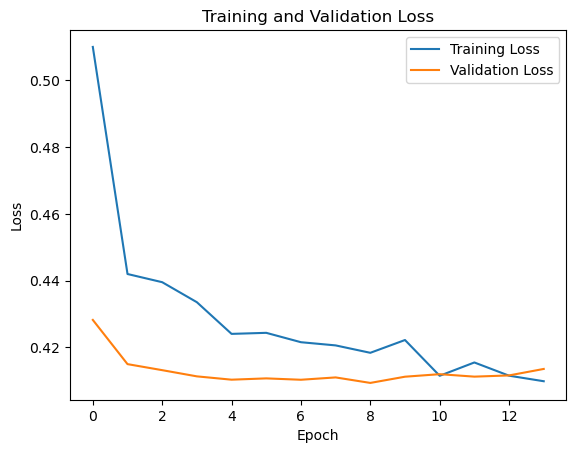

In [41]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.show()


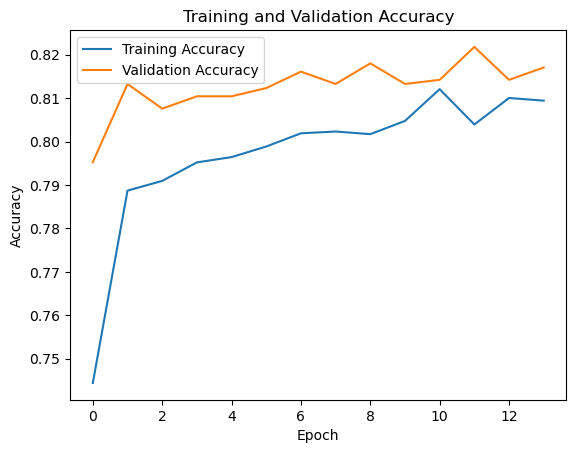

In [42]:
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')
plt.show()

#### Evaluate on the test set



In [43]:
test_loss, test_accuracy = model.evaluate(X_test_scaled, y_test)
print('Testing Loss:', test_loss)
print('Testing Accuracy:', test_accuracy)


33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 474us/step - accuracy: 0.7934 - loss: 0.4410
Testing Loss: 0.44101420044898987
Testing Accuracy: 0.793364942073822


In [44]:
probabilities = model.predict(X_test_scaled)

33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 708us/step


In [45]:
predictions = (probabilities >= 0.5).astype(int)

#### Confusion matrix


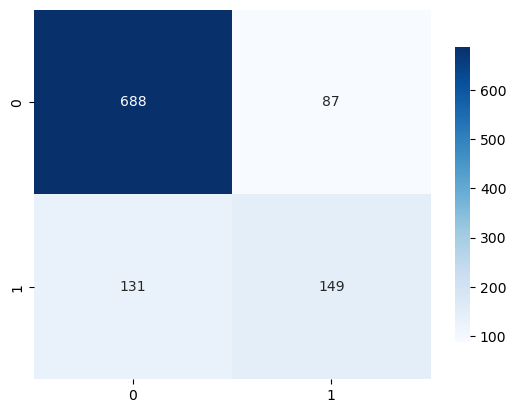

In [46]:
cm = confusion_matrix(y_test, predictions)
sns.heatmap(cm, annot= True, fmt = 'd', cmap = 'Blues', cbar_kws={"shrink": 0.8})
plt.show()



#### Experiment with the decision threshold



In [47]:
from sklearn.metrics import precision_score, recall_score

thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]

for threshold in thresholds:
    prediction_thresholds = (probabilities >= threshold).astype(int)

    precision = precision_score(y_test, prediction_thresholds)

    recall = recall_score(y_test, prediction_thresholds)

    print('Threshold:', prediction_thresholds)
    print('Precision:', precision)
    print('Recall:', recall)
    


Threshold: [[1]
 [0]
 [0]
 ...
 [0]
 [1]
 [0]]
Precision: 0.511002444987775
Recall: 0.7464285714285714
Threshold: [[0]
 [0]
 [0]
 ...
 [0]
 [0]
 [0]]
Precision: 0.558641975308642
Recall: 0.6464285714285715
Threshold: [[0]
 [0]
 [0]
 ...
 [0]
 [0]
 [0]]
Precision: 0.6313559322033898
Recall: 0.5321428571428571
Threshold: [[0]
 [0]
 [0]
 ...
 [0]
 [0]
 [0]]
Precision: 0.6411764705882353
Recall: 0.3892857142857143
Threshold: [[0]
 [0]
 [0]
 ...
 [0]
 [0]
 [0]]
Precision: 0.6794871794871795
Recall: 0.18928571428571428


#### Save the ANN



In [48]:
model.save("customer_churn_ann.keras")
